# Inspect AFTER Dataset Augmentations

Load one LMDB sample, decode its latent and one augmentation latent with an embedding model, then visualize waveform, MIDI, beats, and audio playback.

In [28]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "after").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "after").exists():
            ROOT = parent
            break

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Using repository root: {ROOT}")

Using repository root: /Users/demerle/Documents/PHD/after_work/AFTER_NEW


In [32]:
import pickle

import lmdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
from IPython.display import Audio, display

from after.dataset.audio_example import AudioExample
from after.dataset.dataset import SimpleDataset

In [55]:
# Configuration
DATASET_PATH = "/Users/demerle/Documents/PHD/after_work/AFTER_NEW/data/guitar/processed"
EMB_MODEL_PATH = "/Users/demerle/Documents/PHD/after_work/AFTER_NEW/data/codecs/SPEC_electronic.ts"
SAMPLE_INDEX = 0
AUG_KEY = "z_structure_aug_1"  # e.g. z_structure_aug_0 or z_timbre_aug_0
SAMPLE_RATE = 44100
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(DATASET_PATH)
print(EMB_MODEL_PATH)
print(f"Device: {DEVICE}")

/Users/demerle/Documents/PHD/after_work/AFTER_NEW/data/guitar/processed
/Users/demerle/Documents/PHD/after_work/AFTER_NEW/data/codecs/SPEC_electronic.ts
Device: cpu


In [56]:
dataset = SimpleDataset(path=str(DATASET_PATH), keys="all")
sample = dataset[SAMPLE_INDEX]
available_keys = sorted(sample.keys())

print(f"Dataset size: {len(dataset)}")
print(f"Sample index: {SAMPLE_INDEX}")
print("Available sample keys:")
for key in available_keys:
    print(" ", key)

assert AUG_KEY in sample, f"Augmentation key not found: {AUG_KEY}"

could not load balanced indices from file
['z_structure_aug_0', 'metadata', 'z_timbre_aug_3', 'midi_structure_aug_1', 'z_timbre_aug_2', 'midi_structure_aug_3', 'z_timbre_aug_0', 'z_timbre_aug_1', 'midi', 'midi_structure_aug_0', 'z_structure_aug_1', 'z_structure_aug_2', 'z', 'z_structure_aug_3', 'midi_structure_aug_2']
Dataset size: 4
Sample index: 0
Available sample keys:
  metadata
  midi
  midi_structure_aug_0
  midi_structure_aug_1
  midi_structure_aug_2
  midi_structure_aug_3
  piano_roll_midi
  piano_roll_midi_structure_aug_0
  piano_roll_midi_structure_aug_1
  piano_roll_midi_structure_aug_2
  piano_roll_midi_structure_aug_3
  z
  z_structure_aug_0
  z_structure_aug_1
  z_structure_aug_2
  z_structure_aug_3
  z_timbre_aug_0
  z_timbre_aug_1
  z_timbre_aug_2
  z_timbre_aug_3


In [57]:
metadata = sample["metadata"]
base_z = sample["z"]
aug_z = sample[AUG_KEY]

base_midi = sample.get("midi")
aug_midi_key = AUG_KEY.replace("z_", "midi_")
aug_midi = sample.get(aug_midi_key)

suffix = AUG_KEY[len("z_"):]
base_beats = np.asarray(metadata.get("beats", []), dtype=np.float32)
base_downbeats = np.asarray(metadata.get("downbeats", []), dtype=np.float32)
aug_beats = np.asarray(metadata.get(f"beats_{suffix}", []), dtype=np.float32)
aug_downbeats = np.asarray(metadata.get(f"downbeats_{suffix}", []), dtype=np.float32)

print("Metadata:")
print(metadata)
print(f"Base z shape: {base_z.shape}")
print(f"Aug z shape: {aug_z.shape}")
print(f"Aug midi key: {aug_midi_key} -> {'present' if aug_midi is not None else 'missing'}")
print(f"Base beats: {len(base_beats)}, base downbeats: {len(base_downbeats)}")
print(f"Aug beats: {len(aug_beats)}, aug downbeats: {len(aug_downbeats)}")

Metadata:
{'chunk_index': 0, 'path': '/Users/demerle/Documents/PHD/after_work/AFTER_NEW/data/guitar/Cymatics - Eternity Acoustic Guitar Loop Wet 2 - 75 BPM B Maj.wav'}
Base z shape: (64, 128)
Aug z shape: (64, 128)
Aug midi key: midi_structure_aug_1 -> present
Base beats: 0, base downbeats: 0
Aug beats: 0, aug downbeats: 0


In [58]:
emb_model = torch.jit.load(str(EMB_MODEL_PATH)).to(DEVICE).eval()

def decode_latent(model, z, device=DEVICE):
    z_t = torch.as_tensor(z, dtype=torch.float32, device=device)
    if z_t.ndim == 1:
        z_t = z_t.unsqueeze(0).unsqueeze(0)
    elif z_t.ndim == 2:
        z_t = z_t.unsqueeze(0)
    with torch.no_grad():
        audio = model.decode(z_t)
    audio = audio.detach().cpu().numpy()
    audio = np.squeeze(audio)
    if audio.ndim > 1:
        audio = audio[0]
    return audio.astype(np.float32)

# base_audio = decode_latent(emb_model, base_z)
# aug_audio = decode_latent(emb_model, aug_z)
aug_audio = base_audio = torch.randn((524288))

print(base_audio.shape, aug_audio.shape)

torch.Size([524288]) torch.Size([524288])


In [59]:
def plot_wave_and_beats(ax, audio, beats, downbeats, sr, title):
    duration = len(audio) / sr
    times = np.linspace(0, duration, len(audio))
    ax.plot(times, audio, color="#4a90d9", lw=0.6, alpha=0.9)
    for beat in beats:
        ax.axvline(float(beat), color="#e67e22", lw=0.8, alpha=0.65)
    for downbeat in downbeats:
        ax.axvline(float(downbeat), color="#c0392b", lw=1.4, alpha=0.85)
    ax.set_xlim(0, duration)
    ax.set_ylim(-1.1, 1.1)
    ax.set_title(title)
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(
        handles=[
            mpatches.Patch(color="#e67e22", alpha=0.7, label="Beat"),
            mpatches.Patch(color="#c0392b", alpha=0.9, label="Downbeat"),
        ],
        loc="upper right",
        fontsize=8,
    )

def plot_midi(ax, midi, duration, title):
    if midi is None:
        ax.text(0.5, 0.5, "No MIDI", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlim(0, duration)
        ax.set_title(title)
        ax.set_ylabel("MIDI pitch")
        ax.grid(True, alpha=0.2)
        return

    colors = plt.cm.Set2.colors
    pitches = []
    for inst_idx, inst in enumerate(midi.instruments):
        for note in inst.notes:
            ax.barh(
                note.pitch,
                note.end - note.start,
                left=note.start,
                height=0.8,
                color=colors[inst_idx % len(colors)],
                alpha=0.85,
            )
            pitches.append(note.pitch)

    if pitches:
        ax.set_ylim(min(pitches) - 2, max(pitches) + 2)
    ax.set_xlim(0, duration)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("MIDI pitch")
    ax.grid(True, alpha=0.2)

def plot_sample_pair(base_audio, aug_audio, base_midi, aug_midi, base_beats, base_downbeats, aug_beats, aug_downbeats, sr, aug_key):
    base_duration = len(base_audio) / sr
    aug_duration = len(aug_audio) / sr
    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex="col", height_ratios=[1.2, 1.0])
    plot_wave_and_beats(axes[0, 0], base_audio, base_beats, base_downbeats, sr, "Original audio + beats")
    plot_wave_and_beats(axes[0, 1], aug_audio, aug_beats, aug_downbeats, sr, f"Augmented audio + beats ({aug_key})")
    plot_midi(axes[1, 0], base_midi, base_duration, "Original MIDI")
    plot_midi(axes[1, 1], aug_midi, aug_duration, f"Augmented MIDI ({aug_key.replace('z_', 'midi_')})")
    fig.suptitle(f"Sample {SAMPLE_INDEX} | {Path(metadata['path']).name}", fontsize=13)
    plt.tight_layout()
    plt.show()

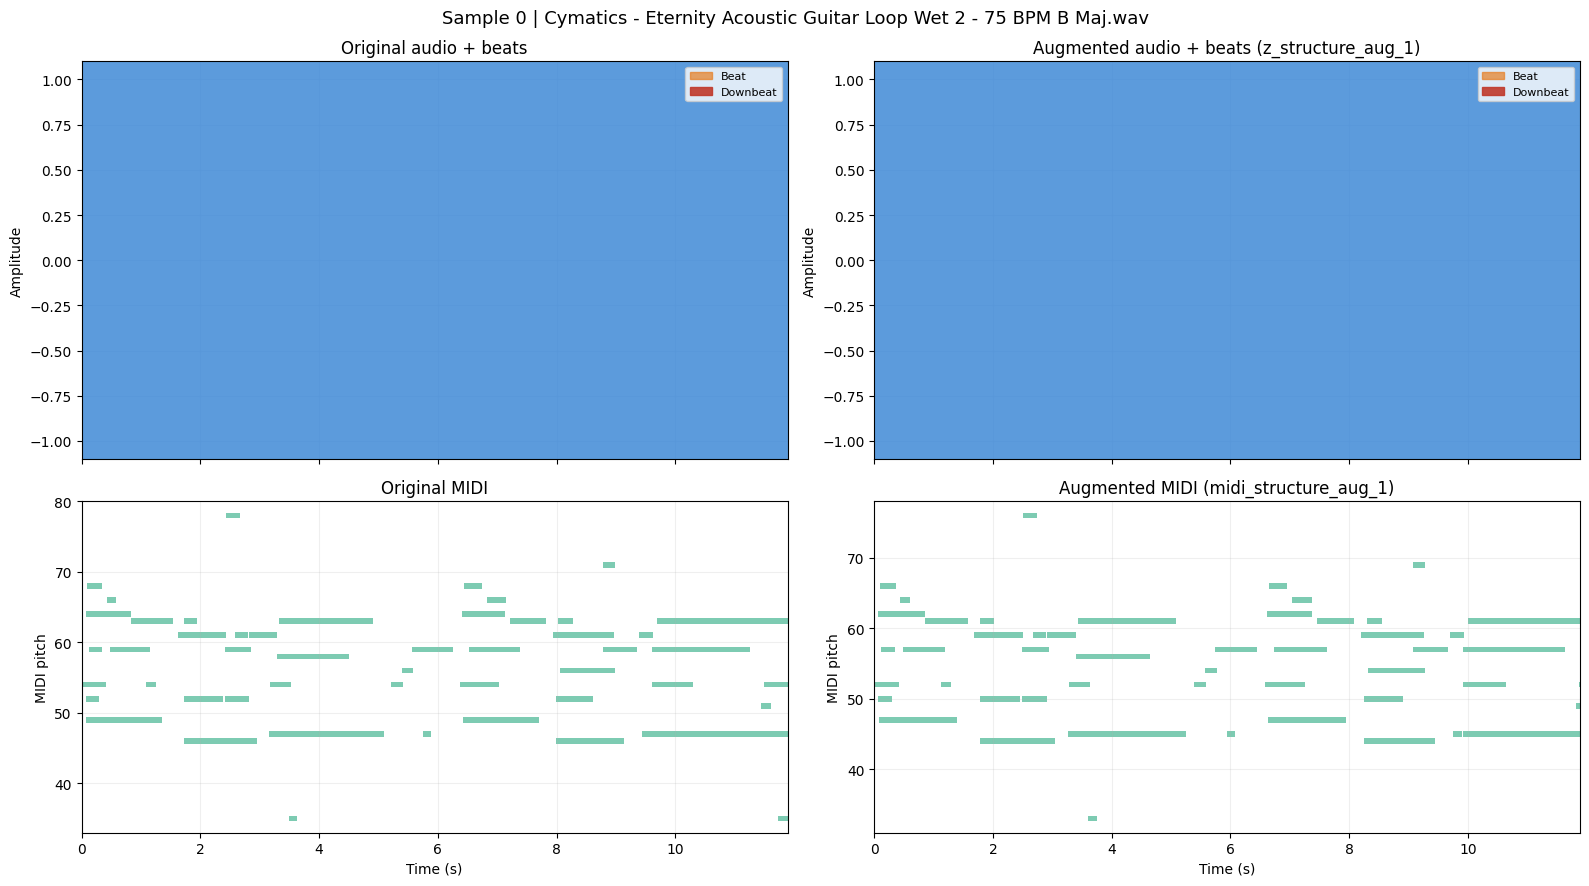

In [60]:
plot_sample_pair(
    base_audio=base_audio,
    aug_audio=aug_audio,
    base_midi=base_midi,
    aug_midi=aug_midi,
    base_beats=base_beats,
    base_downbeats=base_downbeats,
    aug_beats=aug_beats,
    aug_downbeats=aug_downbeats,
    sr=SAMPLE_RATE,
    aug_key=AUG_KEY,
)

In [27]:
print("Original audio")
display(Audio(base_audio, rate=SAMPLE_RATE))
print("Augmented audio")
display(Audio(aug_audio, rate=SAMPLE_RATE))

Original audio


Augmented audio


In [ ]:
# Optional: inspect another augmentation key quickly
sorted([key for key in available_keys if key.startswith("z_") and key != "z"])